In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])

# Excluir columnas no deseadas (incluyendo year y posibles lags para evitar problemas de re-ejecución)
exclude_cols = ["quarter", "fecha", "municipio", "pib_mun_desestacionalizado", "pib_mun_trend", "log_pib_mun_trend", "year"]
medidas_base = [col for col in mont_rad_pib.columns if col not in exclude_cols and not col.endswith("_lag_1") and not col.endswith("_lag_2")]

for col in medidas_base:
    mont_rad_pib[col] = np.log(mont_rad_pib[col])


# Random Forest Regressor sin 'year'

,MSE_log,RMSE_log,MAE_log,MAPE_log,MSE_original,RMSE_original,MAE_original,MAPE_original
mean,0.001813,0.042119,0.033101,0.002686,9.174148e+07,9495.298011,7487.226973,0.033303
std,0.000642,0.006991,0.002194,0.000176,2.827240e+07,1405.700762,613.786203,0.002391


RMSE forecast: 20992.662796
MSE forecast: 440691891.268533
MAE forecast: 20787.337332


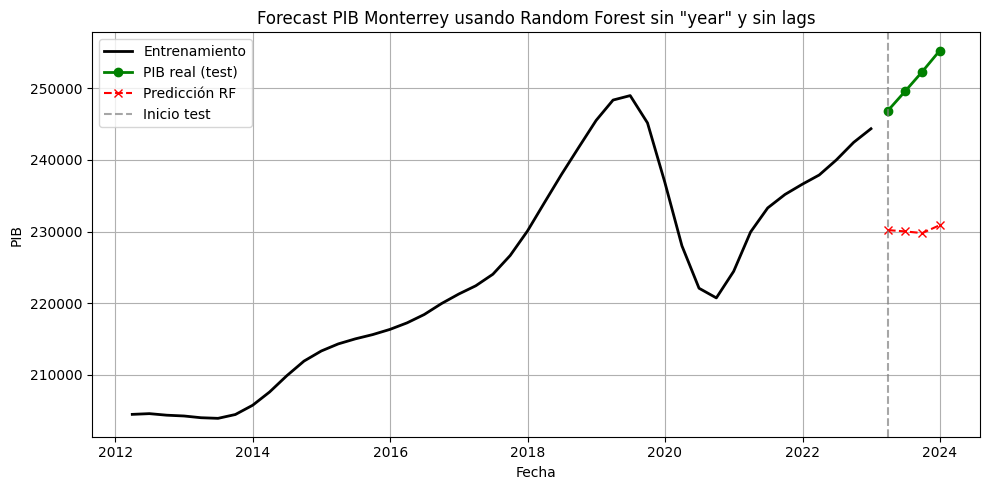

In [7]:
X = mont_rad_pib[medidas_base]
y = mont_rad_pib["log_pib_mun_trend"]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": [],
    "MSE_original": [],
    "RMSE_original": [],
    "MAE_original": [],
    "MAPE_original": []
}

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Métricas en escala logarítmica (y_test y y_pred ya están en log)
    mse_log = mean_squared_error(y_test, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test, y_pred)
    mape_log = np.mean(np.abs((y_test - y_pred) / y_test))
    
    # Métricas en escala original (aplicar exp para revertir el log)
    y_test_original = np.exp(y_test)
    y_pred_original = np.exp(y_pred)
    
    mse_original = mean_squared_error(y_test_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    mape_original = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original))

    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)
    metrics["MSE_original"].append(mse_original)
    metrics["RMSE_original"].append(rmse_original)
    metrics["MAE_original"].append(mae_original)
    metrics["MAPE_original"].append(mape_original)

metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)

# -------- Adecuar forecast con Random Forest para que funcione --------

# Para el forecast, vamos a tomar los últimos periodos de cada municipio como test
# NOTA: Asegúrate de que df_processed, features y 'pib_mun', 'fecha' existen y son correctos.

# Selección de features correctas y consistentes
features = medidas_base  # Usamos las mismas features que arriba

# Si df_processed no existe, crearla a partir de mont_rad_pib para ejemplo Monterrey
# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad con ciclo original
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun_trend'].iloc[:-n_preds].astype(float)  # usar trend o real, ajustar segun disponibilidad
    y_mun_test = df_mun['pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Entrenar modelo
rf_time = RandomForestRegressor(
    n_estimators=100,
    max_leaf_nodes=None,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)

rf_time.fit(X_train, y_train)
y_pred = rf_time.predict(X_test)

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast: {rmse:.6f}")
print(f"MSE forecast: {mse:.6f}")
print(f"MAE forecast: {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando Random Forest sin "year" y sin lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)' if y_train.name == "log_pib_mun_trend" else "PIB")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## TimeSplit CV

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Usar las features con lags ya definidas en el notebook
features = medidas_base

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = df_processed.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['log_pib_mun_trend']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
            n_estimators=100,
            max_leaf_nodes=None,
            max_depth=10,
            min_samples_leaf=1,
            min_samples_split=10,
            random_state=42
        )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df)
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred = np.array(y_pred_hybrid)

    # Métricas globales del fold (en escala logarítmica)
    mse_log = mean_squared_error(y_test_values, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_values, y_pred)
    mape_log = np.mean(np.abs((y_test_values - y_pred) / y_test_values))

    # Métricas en escala original
    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE_log': mse_log,
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'MAPE_log': mape_log,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print("Métricas globales promedio (Monterrey):")
print("="*60)
print(df_global_metrics.mean())
print("\n📋 Métricas por fold:")
print("="*60)
print(df_global_metrics)

# Agregar: imprimir media y std por medida, sin notación científica
print("\n" + "="*60)
print("Media y std por medida (Métricas entre folds):")
print("="*60)
media_std = df_global_metrics.agg(['mean', 'std']).T

# Mostrar todos los valores en formato decimal, no notación científica
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(media_std)



🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

Métricas globales promedio (Monterrey):
MSE_log     1.336557e-02
RMSE_log    9.312192e-02
MAE_log     8.293749e-02
MAPE_log    6.698325e-03
MSE         6.448286e+08
RMSE        2.052291e+04
MAE         1.832785e+04
MAPE        7.691242e+00
dtype: float64

📋 Métricas por fold:
    MSE_log  RMSE_log   MAE_log  MAPE_log           MSE          RMSE  \
0  0.001634  0.040429  0.035363  0.002881  7.184510e+07   8476.148729   
1  0.006742  0.082111  0.068561  0.005563  3.092130e+08  17584.453147   
2  0.002644  0.051415  0.045082  0.003634  1.494933e+08  12226.744387   
3  0.004141  0.064352  0.056419  0.004569  2.100070e+08  14491.618463   
4  0.051666  0.227302  0.209263  0.016846  2.483584e+09  49835.574120   

            MAE       MAPE  
0   7412.530230   3.455899  
1  14700.107527   6.531417  
2  10707.012120   4.378822  
3  12759.754972   5.533285  
4  46059

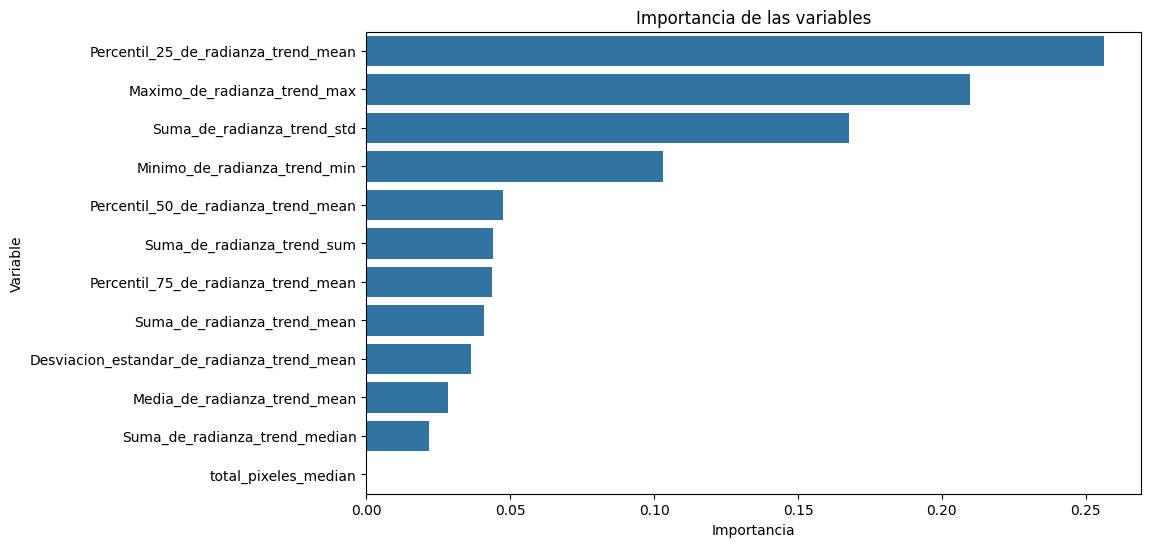

In [9]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by = "Importance", ascending = False)
importance = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, orient="h")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


# Random Forest Regressor con 'Year'

,MSE_log,RMSE_log,MAE_log,MAPE_log,MSE_original,RMSE_original,MAE_original,MAPE_original
mean,0.000519,0.021959,0.017766,0.001440,2.755756e+07,5037.566298,4050.564451,0.017674
std,0.000352,0.006812,0.005574,0.000449,1.947712e+07,1650.942359,1332.621318,0.005367


RMSE forecast: 5976.402057
MSE forecast: 35717381.543411
MAE forecast: 5124.334707


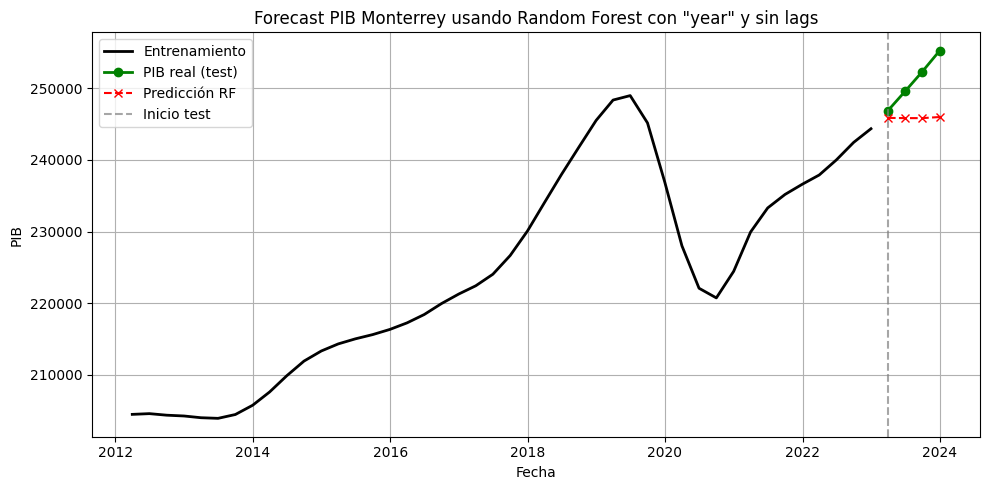

In [10]:
mont_rad_pib["year"] = mont_rad_pib["fecha"].dt.year

# Crear lista de features con year (sin mutar medidas_base)
medidas_con_year = medidas_base.copy()
medidas_con_year.append("year")

X = mont_rad_pib[medidas_con_year]
y = mont_rad_pib["log_pib_mun_trend"]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": [],
    "MSE_original": [],
    "RMSE_original": [],
    "MAE_original": [],
    "MAPE_original": []
}

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Métricas en escala logarítmica (y_test y y_pred ya están en log)
    mse_log = mean_squared_error(y_test, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test, y_pred)
    mape_log = np.mean(np.abs((y_test - y_pred) / y_test))
    
    # Métricas en escala original (aplicar exp para revertir el log)
    y_test_original = np.exp(y_test)
    y_pred_original = np.exp(y_pred)
    
    mse_original = mean_squared_error(y_test_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    mae_original = mean_absolute_error(y_test_original, y_pred_original)
    mape_original = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original))

    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)
    metrics["MSE_original"].append(mse_original)
    metrics["RMSE_original"].append(rmse_original)
    metrics["MAE_original"].append(mae_original)
    metrics["MAPE_original"].append(mape_original)

metrics = pd.DataFrame(metrics)
metrics_summary = metrics.agg(["mean", "std"])
display(metrics_summary)

# -------- Adecuar forecast con Random Forest para que funcione --------

# Para el forecast, vamos a tomar los últimos periodos de cada municipio como test
# NOTA: Asegúrate de que df_processed, features y 'pib_mun', 'fecha' existen y son correctos.

# Selección de features correctas y consistentes
features = medidas_con_year  # Usamos las mismas features que arriba

# Si df_processed no existe, crearla a partir de mont_rad_pib para ejemplo Monterrey
# Para Monterrey solo hay un municipio, así que ajustamos el forecast para ese escenario:
df_processed = mont_rad_pib.copy()
df_processed["municipio_monterrey"] = 1  # Dummy fix por compatibilidad con ciclo original
municipios = ["monterrey"]

n_preds = 4

X_train = pd.DataFrame(columns=features, dtype=float)
X_test = pd.DataFrame(columns=features, dtype=float)
y_train = pd.Series(dtype=float)
y_test = pd.Series(dtype=float)

# Para Monterrey, solo necesitamos filtrar y tomar los últimos n_preds como test
for mun in municipios:
    if f'municipio_{mun}' in df_processed.columns:
        col = f'municipio_{mun}'
        df_mun = df_processed[df_processed[col] == 1].sort_values('fecha').copy()
    else:
        df_mun = df_processed.sort_values('fecha').copy()

    if len(df_mun) <= n_preds:
        continue

    # Dividir en train/test
    X_mun_train = df_mun[features].iloc[:-n_preds].astype(float)
    X_mun_test = df_mun[features].iloc[-n_preds:].astype(float)
    y_mun_train = df_mun['pib_mun_trend'].iloc[:-n_preds].astype(float)  # usar trend o real, ajustar segun disponibilidad
    y_mun_test = df_mun['pib_mun_trend'].iloc[-n_preds:].astype(float)

    # Concatenar
    X_train = pd.concat([X_train, X_mun_train])
    X_test = pd.concat([X_test, X_mun_test])
    y_train = pd.concat([y_train, y_mun_train])
    y_test = pd.concat([y_test, y_mun_test])

# Entrenar modelo
rf_time = RandomForestRegressor(
    n_estimators=100,
    max_leaf_nodes=None,
    max_depth=10,
    min_samples_leaf=1,
    random_state=42
)

rf_time.fit(X_train, y_train)
y_pred = rf_time.predict(X_test)

# Métricas forecast
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"RMSE forecast: {rmse:.6f}")
print(f"MSE forecast: {mse:.6f}")
print(f"MAE forecast: {mae:.6f}")

# Preparar datos para visualización
df_train = df_processed.loc[X_train.index].copy()
df_train['y_real'] = y_train

df_test = df_processed.loc[X_test.index].copy()
df_test['y_real'] = y_test
df_test['y_pred'] = y_pred

# Graficar el forecast para Monterrey
for m in municipios:
    if f'municipio_{m}' in df_test.columns:
        col = f'municipio_{m}'
        df_mun_train = df_train[df_train[col] == 1].sort_values('fecha')
        df_mun_test = df_test[df_test[col] == 1].sort_values('fecha')
    else:
        df_mun_train = df_train.sort_values('fecha')
        df_mun_test = df_test.sort_values('fecha')

    if df_mun_train.empty and df_mun_test.empty:
        continue

    plt.figure(figsize=(10, 5))

    # PIB real en train
    if not df_mun_train.empty:
        plt.plot(df_mun_train['fecha'], df_mun_train['y_real'],
                 label='Entrenamiento', color='black', linewidth=2)

    # PIB real en test y predicciones
    if not df_mun_test.empty:
        plt.plot(df_mun_test['fecha'], df_mun_test['y_real'],
                 label='PIB real (test)', color='green', linewidth=2, marker='o')
        plt.plot(df_mun_test['fecha'], df_mun_test['y_pred'],
                 label='Predicción RF', color='red', linestyle='--', marker='x')
        plt.axvline(x=df_mun_test['fecha'].iloc[0], color='gray',
                   linestyle='--', alpha=0.7, label='Inicio test')

    plt.title(f'Forecast PIB Monterrey usando Random Forest con "year" y sin lags')
    plt.xlabel('Fecha')
    plt.ylabel('log(PIB)' if y_train.name == "log_pib_mun_trend" else "PIB")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## TimeSplit CV

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# Usar las features con lags ya definidas en el notebook
features = medidas_con_year

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_global_metrics = []

# Asegurarse de que el df esté ordenado por fecha
df_processed_sorted = df_processed.sort_values('fecha').reset_index(drop=True)

X = df_processed_sorted[features]
y = df_processed_sorted['log_pib_mun_trend']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n🔄 Processing Fold {fold}/{n_splits}...")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Escalar X e y
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

    # Convertir X escalados de vuelta a DataFrame para mantener nombres de columnas
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Paso 1: Entrenar OLS en datos escalados
    X_train_ols = sm.add_constant(X_train_scaled_df)
    ols_model = sm.OLS(y_train_scaled, X_train_ols).fit()
    y_hat_train_ols = ols_model.predict(X_train_ols)
    residuals_train = y_train_scaled - y_hat_train_ols

    # Paso 2: Entrenar RF en los residuales
    rf = RandomForestRegressor(
            n_estimators=100,
            max_leaf_nodes=None,
            max_depth=10,
            min_samples_leaf=1,
            min_samples_split=10,
            random_state=42
        )
    rf.fit(X_train_scaled_df, residuals_train)

    # Paso 3: Predicción híbrida en test (escalado)
    X_test_ols = sm.add_constant(X_test_scaled_df)
    y_hat_test_ols_scaled = ols_model.predict(X_test_ols)
    y_hat_test_rf_scaled = rf.predict(X_test_scaled_df)
    y_pred_hybrid_scaled = y_hat_test_ols_scaled + y_hat_test_rf_scaled

    # Desescalar las predicciones
    y_pred_hybrid = scaler_y.inverse_transform(y_pred_hybrid_scaled.values.reshape(-1, 1)).ravel()

    # Convertir todo a numpy arrays del mismo tamaño
    y_test_values = y_test.values
    y_pred = np.array(y_pred_hybrid)

    # Métricas globales del fold (en escala logarítmica)
    mse_log = mean_squared_error(y_test_values, y_pred)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_values, y_pred)
    mape_log = np.mean(np.abs((y_test_values - y_pred) / y_test_values))

    # Métricas en escala original
    y_test_real = np.exp(y_test_values)
    y_pred_real = np.exp(y_pred)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

    fold_global_metrics.append({
        'MSE_log': mse_log,
        'RMSE_log': rmse_log,
        'MAE_log': mae_log,
        'MAPE_log': mape_log,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

# Métricas globales promedio entre folds
df_global_metrics = pd.DataFrame(fold_global_metrics)
print("\n" + "="*60)
print("Métricas globales promedio (Monterrey):")
print("="*60)
print(df_global_metrics.mean())
print("\n📋 Métricas por fold:")
print("="*60)
print(df_global_metrics)

# Agregar: imprimir media y std por medida, sin notación científica
print("\n" + "="*60)
print("Media y std por medida (Métricas entre folds):")
print("="*60)
media_std = df_global_metrics.agg(['mean', 'std']).T

# Mostrar todos los valores en formato decimal, no notación científica
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(media_std)



🔄 Processing Fold 1/5...

🔄 Processing Fold 2/5...

🔄 Processing Fold 3/5...

🔄 Processing Fold 4/5...

🔄 Processing Fold 5/5...

Métricas globales promedio (Monterrey):
MSE_log     3.133060e-03
RMSE_log    5.070878e-02
MAE_log     4.397055e-02
MAPE_log    3.562771e-03
MSE         1.541890e+08
RMSE        1.135369e+04
MAE         9.847228e+03
MAPE        4.293923e+00
dtype: float64

📋 Métricas por fold:
    MSE_log  RMSE_log   MAE_log  MAPE_log           MSE          RMSE  \
0  0.001598  0.039971  0.035655  0.002905  7.027445e+07   8382.985658   
1  0.007990  0.089386  0.076552  0.006212  3.634951e+08  19065.548146   
2  0.003510  0.059248  0.054199  0.004368  1.977611e+08  14062.755018   
3  0.002267  0.047618  0.038948  0.003160  1.214733e+08  11021.493925   
4  0.000300  0.017321  0.014499  0.001169  1.794105e+07   4235.687814   

            MAE      MAPE  
0   7474.651544  3.486923  
1  16347.933029  7.271139  
2  12834.740346  5.248379  
3   9025.232379  4.008041  
4   3553.5811

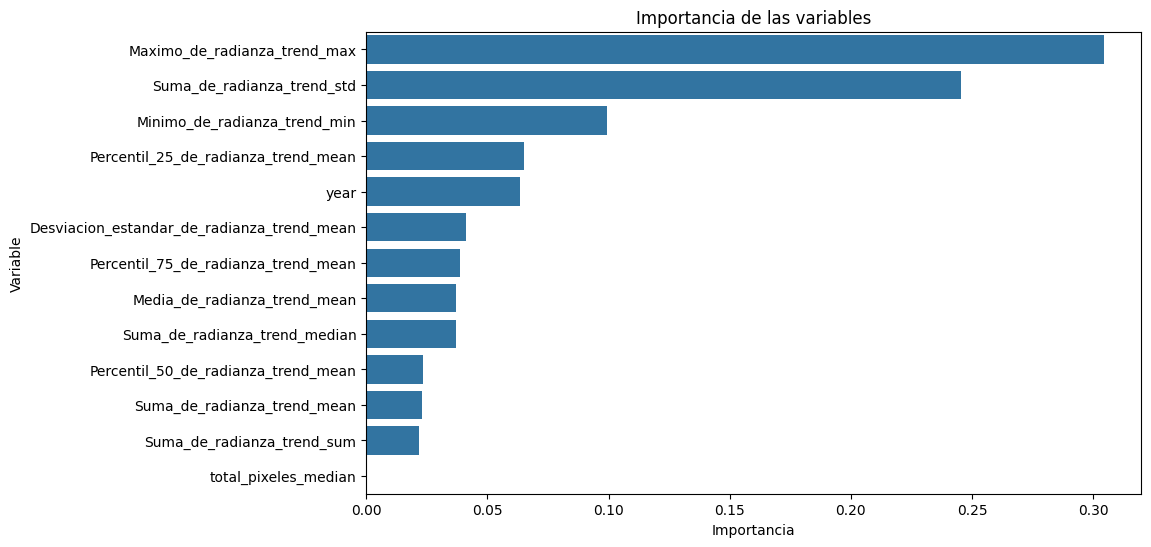

In [12]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by = "Importance", ascending = False)
importance = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, orient="h")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()
